<a href="https://colab.research.google.com/github/khalilhaddad7/Power-Plant-Energy-Output-Prediction-using-Machine-Learning/blob/main/Power%20Plant%20Energy%20Output%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/Folds5x2_pp.csv")


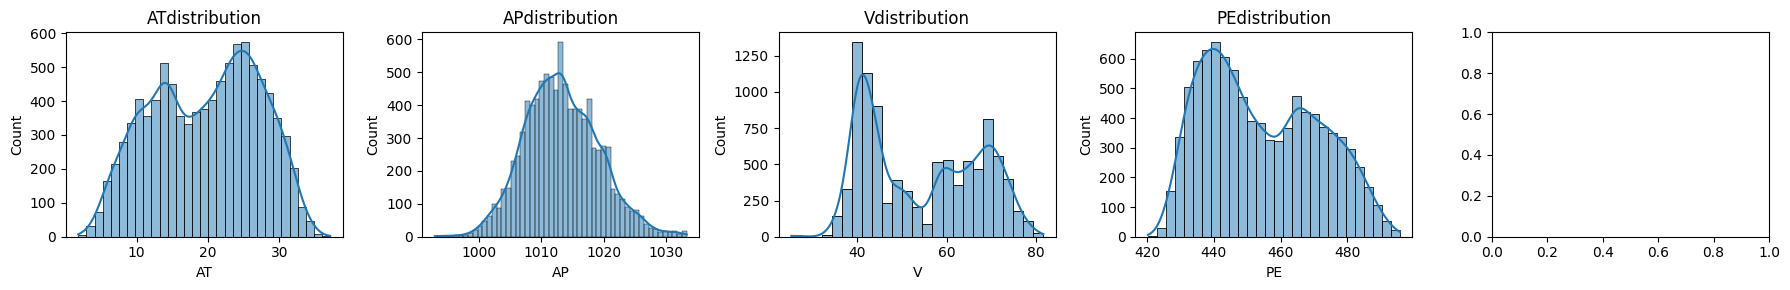

In [ ]:
fig,axes = plt.subplots(1,5,figsize=(18,3))
for ax, col in zip(axes,['AT','AP','V','PE']):
  sns.histplot(df[col],kde=True ,ax=ax)
  ax.set_title(f'{col}distribution')
plt.tight_layout();plt.show()

In [ ]:
import plotly.express as px
fig = px.scatter_3d(df ,x='AT',y='AP',z='V',color='PE',color_continuous_scale='viridis',title='3D View:ambient conditions vs energy output(PE)')
fig.show()

<Axes: >

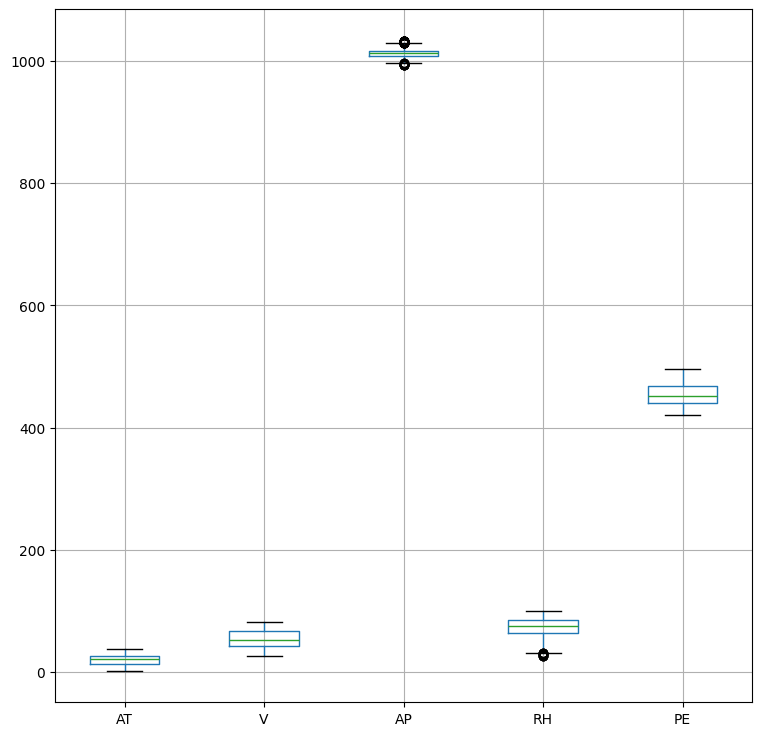

In [ ]:
plt.figure(figsize=(9,9))
df.boxplot()


/tmp/ipython-input-2564440879.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2564440879.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




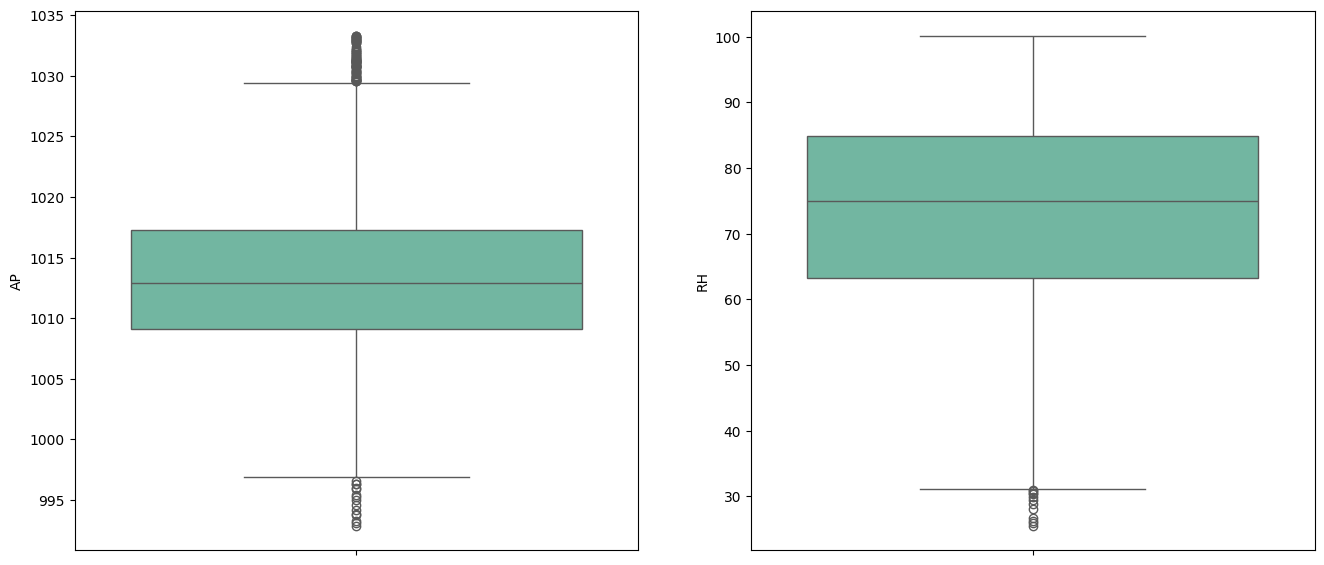

In [ ]:
fig , axes = plt.subplots(1,2,figsize=(16,7))
sns.boxplot(data=df["AP"],orient="v",ax=axes[0],palette="Set2")
sns.boxplot(data=df["RH"],orient="v",ax=axes[1],palette="Set2")
plt.show()

In [ ]:
k = 1.5
features = ['AT','AP','V','PE']
target = 'PE'
df_raw = df.copy()
cols = features + [target]
mask = np.ones(len(df_raw),dtype=bool)
for c in cols:
  Q1 = df_raw[c].quantile(0.25)
  Q3 = df_raw[c].quantile(0.75)
  IQR = Q3 - Q1
  low, high = Q1 - k*IQR, Q3 + k*IQR
  mask &= ((df_raw[c] >= low) & (df_raw[c] <= high))
df_clean = df_raw[mask].copy()
print(f"Rows BEFORE IQR:{len(df_raw)}")
print(f"Rows AFTER IQR:{len(df_clean)}")
print(f"Rows REMOVED:{len(df_raw) - len(df_clean)}"
f"({(len(df_raw) - len(df_clean))/len(df_raw):.2f})")

Rows BEFORE IQR:9568
Rows AFTER IQR:9480
Rows REMOVED:88(0.01)


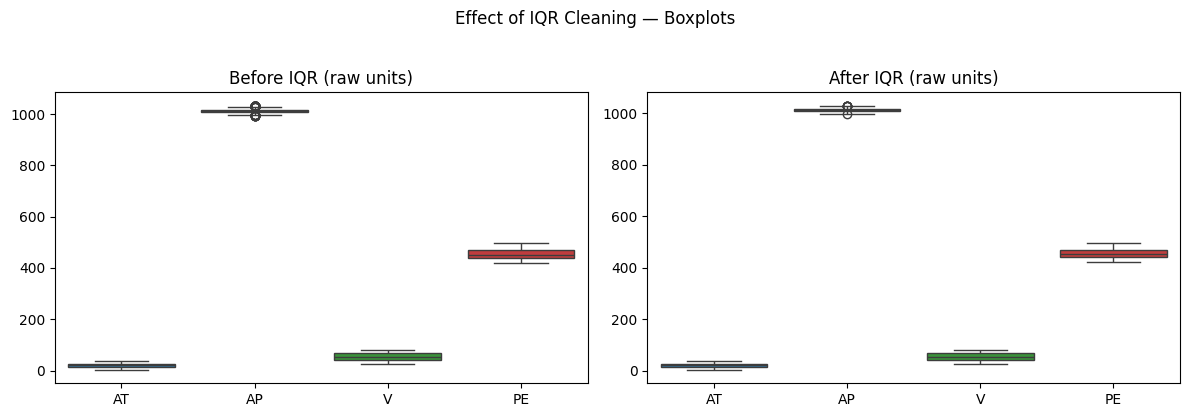

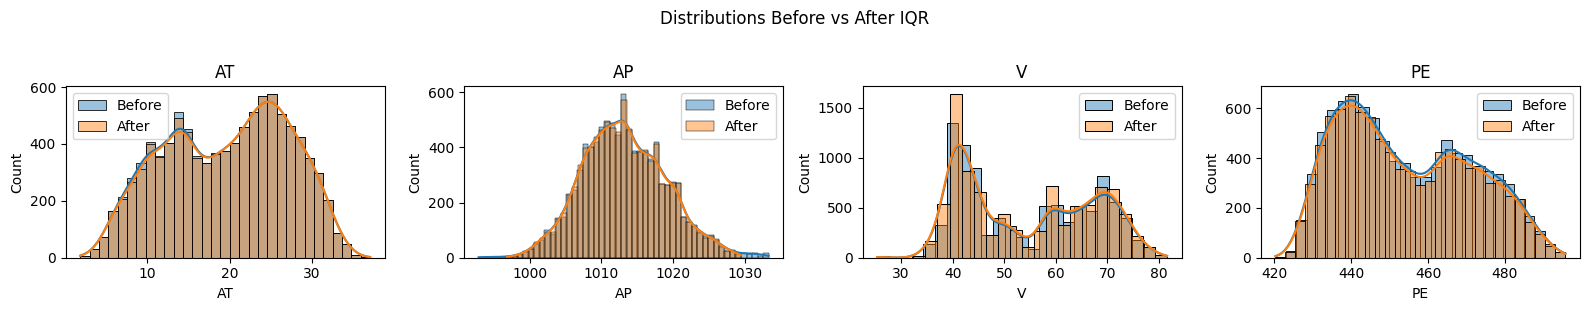

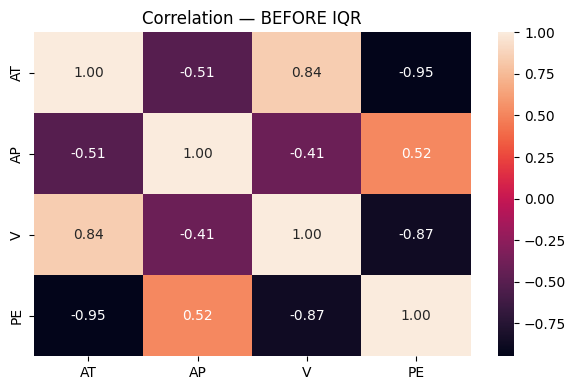

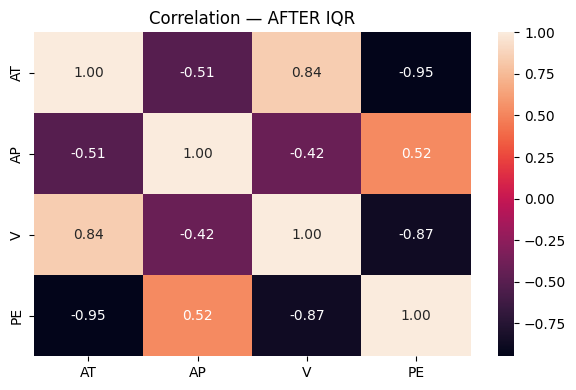

In [ ]:
# ===============================================================
# VISUALIZATIONS: EFFECT OF IQR CLEANING
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Boxplots AVANT vs APRÈS (unités brutes)
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=False)
sns.boxplot(data=df_raw[features], ax=axes[0])
axes[0].set_title('Before IQR (raw units)')
sns.boxplot(data=df_clean[features], ax=axes[1])
axes[1].set_title('After IQR (raw units)')
plt.suptitle('Effect of IQR Cleaning — Boxplots', y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

# 2) Distributions (hist+KDE) AVANT/APRÈS pour chaque feature
cols = features
ncols = 4; nrows = int(np.ceil(len(cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_raw[col], kde=True, ax=axes[i], label='Before', alpha=0.45)
    sns.histplot(df_clean[col], kde=True, ax=axes[i], label='After',  alpha=0.45)
    axes[i].set_title(col)
    axes[i].legend()

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.suptitle('Distributions Before vs After IQR', y=1.02); plt.tight_layout(); plt.show()

# 3) Heatmaps de corrélation AVANT/APRÈS
plt.figure(figsize=(6,4))
sns.heatmap(df_raw[cols].corr(), annot=True, fmt='.2f')
plt.title('Correlation — BEFORE IQR'); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df_clean[cols].corr(), annot=True, fmt='.2f')
plt.title('Correlation — AFTER IQR'); plt.tight_layout(); plt.show()


In [ ]:
import time
target = 'PE'
x= df.drop(columns='PE',axis=1)
y= df['PE']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7654, 4)
(1914, 4)
(7654,)
(1914,)


Training time: 0.0019seconds
Linear Regression Performance:
R2 Score: 0.9315
Mean Absolute Error: 3.543
Mean Squared Error: 19.608
Root Mean Squared Error: 4.428


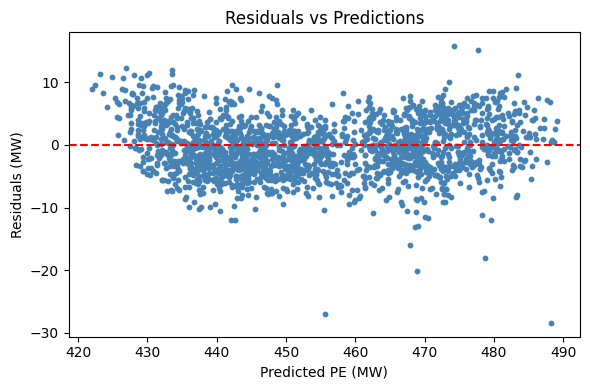

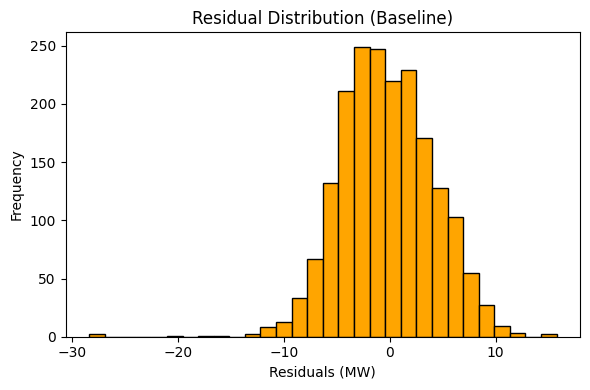

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import time
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)
model = LinearRegression()
t0= time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time()-t0
t0= time.time()- t0
print(f"Training time: {train_time:.4f}seconds")
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Linear Regression Performance:")
print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.3f}")
print(f"Mean Squared Error: {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")
residuals = y_test - y_pred
# a) Residuals vs Predicted

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, s=10, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PE (MW)")
plt.ylabel("Residuals (MW)")
plt.title("Residuals vs Predictions")
plt.tight_layout()
plt.show()
#this plot shows how much the model is wrong for each prediction.
# b) Residual Distribution
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, color='orange', edgecolor='black')
plt.title("Residual Distribution (Baseline)")
plt.xlabel("Residuals (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# --- Save baseline metrics for later comparison ---
baseline_r2  = r2
baseline_mae = mae
baseline_rmse = rmse

In [ ]:
df['PE'].describe()

,PE
count,9568.000000
mean,454.365009
std,17.066995
min,420.260000
25%,439.750000
50%,451.550000
75%,468.430000
max,495.760000


In [ ]:
# ===============================================================
# Linear Regression After Outlier Removal Using the IQR Method
# ===============================================================

# 0) Use the cleaned DataFrame from preprocessing
# df_clean
# 1) Train/test split (on already-cleaned data)
import time
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
features = ['AT','AP','RH','V']
target = 'PE'
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) Standardization (fit on TRAIN only, transform TEST)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3) Train
model = LinearRegression()
t0 = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - t0

# 4) Predict
y_pred = model.predict(X_test_scaled)

# 5) Evaluate
iqr_r2  = r2_score(y_test, y_pred)
iqr_mae = mean_absolute_error(y_test, y_pred)
iqr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n🔹 Linear Regression after IQR Cleaning")
print(f"Training time : {train_time:.4f} s")
print(f"R² Score      : {iqr_r2:.4f}")
print(f"MAE           : {iqr_mae:.3f}")
print(f"RMSE          : {iqr_rmse:.3f}")


🔹 Linear Regression after IQR Cleaning
Training time : 0.0023 s
R² Score      : 0.9268
MAE           : 3.612
RMSE          : 4.535


In [ ]:
import pandas as pd
comparison = pd.DataFrame({
    'R2' : [baseline_r2, iqr_r2],
    'MAE' : [baseline_mae, iqr_mae],
    'RMSE' : [baseline_rmse, iqr_rmse]
}, index=['Linear Regression (no cleaning)', 'Linear Regression after (IQR)'])
display(comparison)


,R2,MAE,RMSE
Linear Regression (no cleaning),0.931475,3.543448,4.428102
Linear Regression after (IQR),0.926773,3.611582,4.534924


In [ ]:
# ===============================================================
# MODEL COMPARISON — Decision Tree, KNN, SVR, Random Forest
# ===============================================================

results_reg = []
times_reg = {}
def regression_report(y_true, y_hat, label='Model'):
    r2 = r2_score(y_true, y_hat)
    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    #print(f'{label} -> R2={r2:.4f} | MAE={mae:.3f} | RMSE={rmse:.3f}')
    return {'model':label, 'R2':r2, 'MAE':mae, 'RMSE':rmse}
def fit_eval_reg(name, estimator):
    t0 = time.time()
    estimator.fit(X_train, y_train)
    train_t = time.time() - t0
    y_hat = estimator.predict(X_test)
    metrics = regression_report(y_test, y_hat, name)
    results_reg.append(metrics)
    times_reg[name] = train_t

fit_eval_reg('DecisionTreeRegressor', DecisionTreeRegressor(random_state=RANDOM_STATE))
fit_eval_reg('KNNRegressor', Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor())]))
fit_eval_reg('SVR', Pipeline([('scaler', StandardScaler()), ('model', SVR())]))
fit_eval_reg('RandomForestRegressor', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE))

reg_df = pd.DataFrame(results_reg).set_index('model').sort_values('RMSE')
reg_df


NameError: name 'DecisionTreeRegressor' is not defined

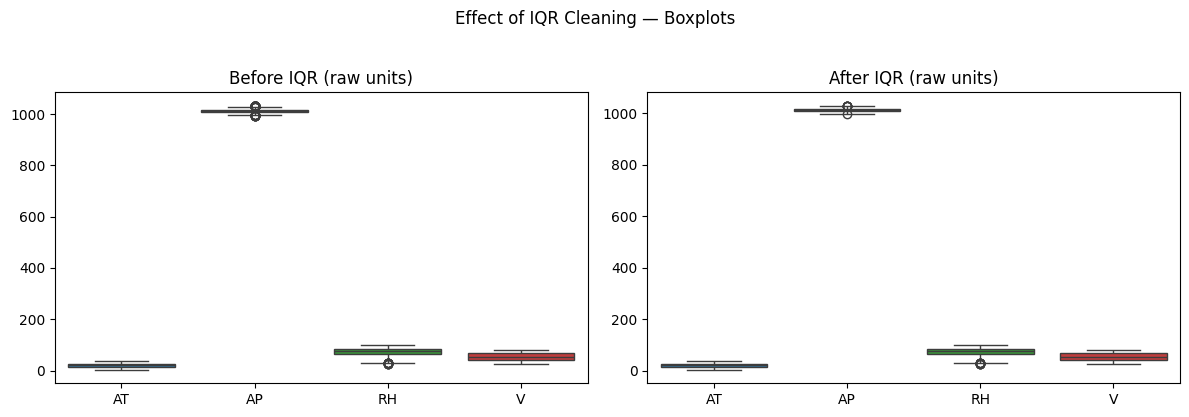

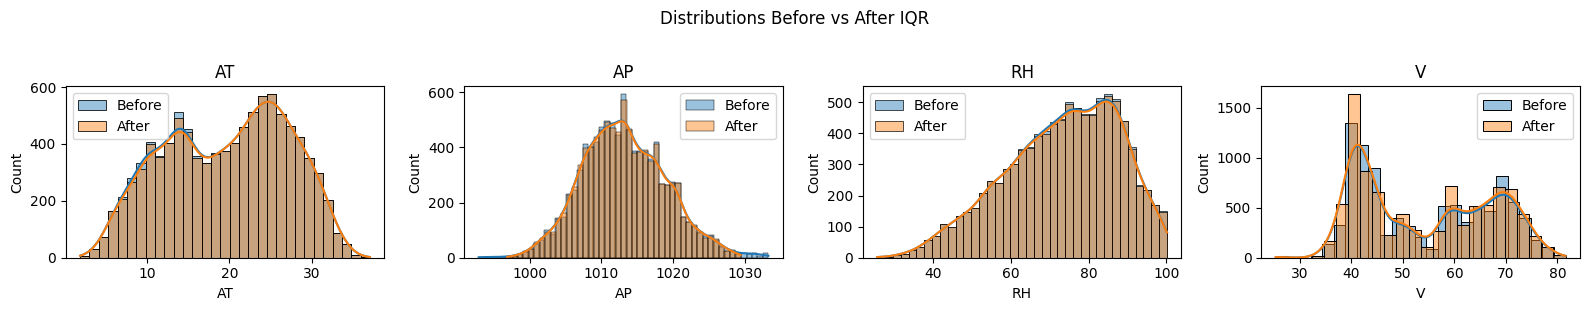

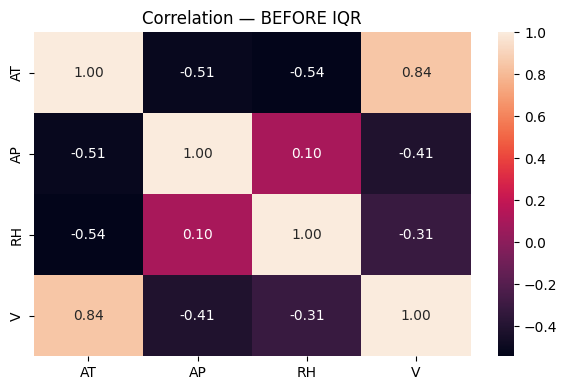

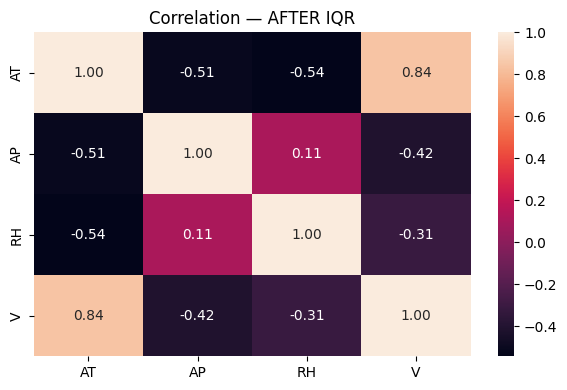

In [ ]:
# ===============================================================
# VISUALIZATIONS: EFFECT OF IQR CLEANING
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Boxplots AVANT vs APRÈS (unités brutes)
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=False)
sns.boxplot(data=df_raw[features], ax=axes[0])
axes[0].set_title('Before IQR (raw units)')
sns.boxplot(data=df_clean[features], ax=axes[1])
axes[1].set_title('After IQR (raw units)')
plt.suptitle('Effect of IQR Cleaning — Boxplots', y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

# 2) Distributions (hist+KDE) AVANT/APRÈS pour chaque feature
cols = features
ncols = 4; nrows = int(np.ceil(len(cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_raw[col], kde=True, ax=axes[i], label='Before', alpha=0.45)
    sns.histplot(df_clean[col], kde=True, ax=axes[i], label='After',  alpha=0.45)
    axes[i].set_title(col)
    axes[i].legend()

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.suptitle('Distributions Before vs After IQR', y=1.02); plt.tight_layout(); plt.show()

# 3) Heatmaps de corrélation AVANT/APRÈS
plt.figure(figsize=(6,4))
sns.heatmap(df_raw[cols].corr(), annot=True, fmt='.2f')
plt.title('Correlation — BEFORE IQR'); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df_clean[cols].corr(), annot=True, fmt='.2f')
plt.title('Correlation — AFTER IQR'); plt.tight_layout(); plt.show()


ValueError: x and y must be the same size

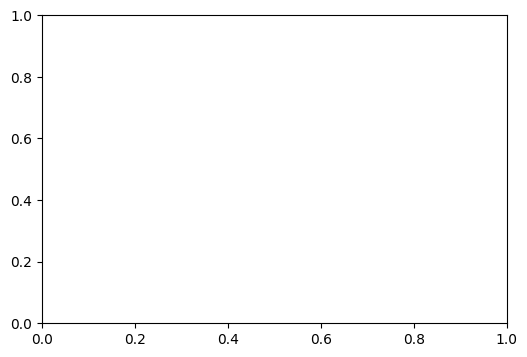

In [ ]:
# a) Residuals vs Predicted

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, s=10, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PE (MW)")
plt.ylabel("Residuals (MW)")
plt.title("Residuals vs Predictions")
plt.tight_layout()
plt.show()
#this plot shows how much the model is wrong for each prediction.
# b) Residual Distribution
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, color='orange', edgecolor='black')
plt.title("Residual Distribution (Baseline)")
plt.xlabel("Residuals (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# --- Save baseline metrics for later comparison ---
baseline_r2  = r2
baseline_mae = mae
baseline_rmse = rmse

NameError: name 'reg_df' is not defined

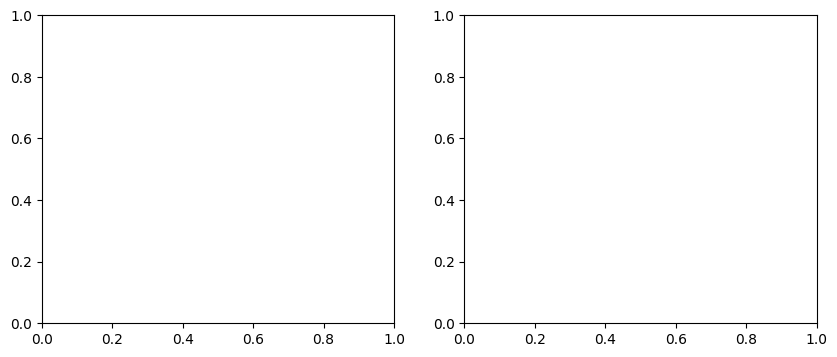

In [ ]:
# ===============================================================
# BARPLOTS — RMSE (lower=better) and R² (higher=better)
# ===============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# RMSE
reg_df["RMSE"].plot(kind="bar", ax=axes[0], color="tomato", edgecolor="black")
axes[0].set_title("Test RMSE (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=15)

# R2
reg_df["R2"].plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Test R² (higher is better)")
axes[1].set_ylabel("R²")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ===============================================================
# TRAINING TIME (seconds)
# ===============================================================
import pandas as pd

times_df = pd.Series(times_reg).sort_index()
plt.figure(figsize=(6,4))
times_df.plot(kind="bar", edgecolor="black")
plt.title("Training Time (s)")
plt.ylabel("Seconds")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()